In [ ]:
import ll_vec as lv
import ll  as ll
import matplotlib.pyplot as plt
import time
import LLcython as lcy
import ll_checker as lc
import ll_vect_numba as lvn
import ll_numba as ln
import ll_checker_numba as lcn
import LLcython_pra as llp
test_inputs = [
    ("LL", 10, 50, 0.5, 0),
    ("LL", 100, 50, 0.5, 0),
    ("LL", 500, 50, 0.5, 0),
    ("LL", 1000, 50, 0.5, 0),
]


In [12]:
def program_time (module_name, test_inputs):
    input_values = []
    duration = []
    for program, nsteps, nmax, temp, pflag in test_inputs:
        input_values.append(nsteps)

        start = time.perf_counter()
        module_name(program, nsteps, nmax, temp, pflag )
        end = time.perf_counter()

        duration.append(end - start)
    return input_values, duration

In [13]:
values1, results1 = program_time(ll.main,test_inputs)
values2, results2 = program_time(lv.main,test_inputs)
values3, results3 = program_time(lcy.main, test_inputs)
values4, results4 = program_time(lc.main, test_inputs)
values5, results5 = program_time(lvn.main, test_inputs)
values6, results6 = program_time(ln.main, test_inputs)
values7, results7 = program_time(lcn.main, test_inputs)

LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.333, Time: 0.995150 s
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.340, Time: 11.197219 s
LL: Size: 50, Steps: 500, T*: 0.500: Order: 0.585, Time: 48.373924 s
LL: Size: 50, Steps: 1000, T*: 0.500: Order: 0.494, Time: 99.210760 s
LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.267, Time: 0.499834 s
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.405, Time: 5.468160 s
LL: Size: 50, Steps: 500, T*: 0.500: Order: 0.470, Time: 29.660946 s
LL: Size: 50, Steps: 1000, T*: 0.500: Order: 0.644, Time: 377.317839 s
LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.278, Time: 0.263266 s
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.286, Time: 2.672716 s
LL: Size: 50, Steps: 500, T*: 0.500: Order: 0.325, Time: 15.071627 s
LL: Size: 50, Steps: 1000, T*: 0.500: Order: 0.376, Time: 26.740299 s
LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.285, Time: 0.028224 s
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.369, Time: 0.237786 s
LL: Size: 50, Steps: 500, T*: 0.500: Orde

print(values1,
results1,
values2,
results2,
values3,
results3,
values4,
results4)

In [14]:
test2_inputs = [
    ("LL", 10, 50, 0.5, 0,1),
    ("LL", 100, 50, 0.5, 0,1),
    ("LL", 500, 50, 0.5, 0,1),
    ("LL", 1000, 50, 0.5, 0,1),
]

In [20]:
def program_time_2 (module_name, test_inputs):
    input_values = []
    duration = []
    for program, nsteps, nmax, temp, pflag, thread in test2_inputs:
        input_values.append(nsteps)

        start = time.perf_counter()
        module_name(program, nsteps, nmax, temp, pflag,thread)
        end = time.perf_counter()

        duration.append(end - start)
    return input_values, duration

In [22]:
values8, results8 = program_time_2(llp.main, test2_inputs)

LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.282, Time: 0.195975 s
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.303, Time: 2.000805 s
LL: Size: 50, Steps: 500, T*: 0.500: Order: 0.330, Time: 11.755021 s
LL: Size: 50, Steps: 1000, T*: 0.500: Order: 0.276, Time: 20.775695 s


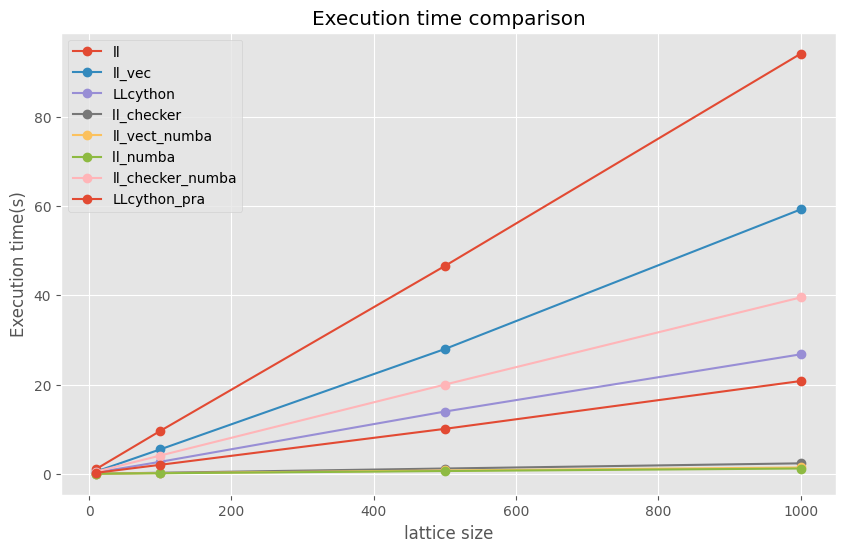

In [23]:

fig, ax = plt.subplots(figsize = (10, 6))
plt.style.use('ggplot')
data_dict = {
    'll': (values1, results1),
    'll_vec':(values2, results2),
    'LLcython':(values3, results3),
    'll_checker ':(values4, results4),
    'll_vect_numba':(values5, results5),
    'll_numba ':(values6, results6),
    'll_checker_numba':(values7, results7),
    'LLcython_pra':(values8, results8)
}

for label, (x, y) in data_dict.items():
    plt.plot(x, y, label = label, marker = 'o', linestyle ='-')

plt.title('Execution time comparison')
plt.xlabel('lattice size')
plt.ylabel('Execution time(s)')
plt.legend()
plt.show()

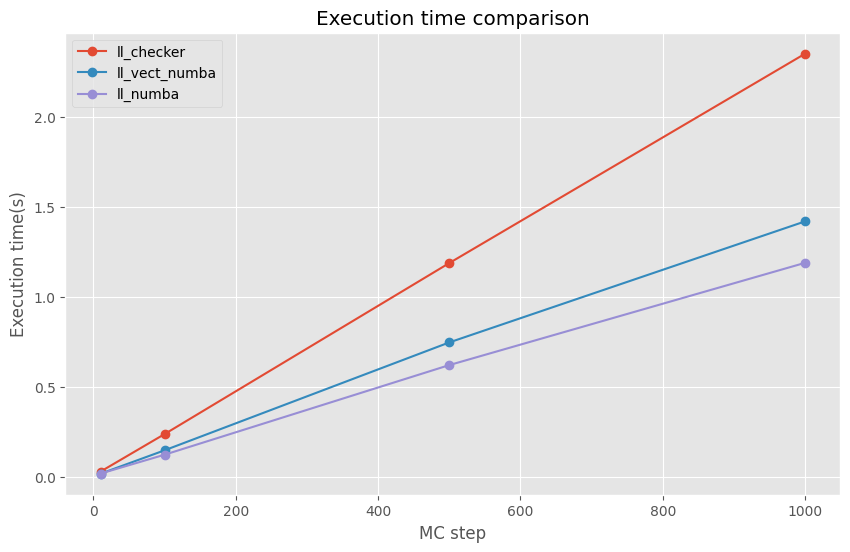

In [24]:
fig, ax = plt.subplots(figsize = (10, 6))
plt.style.use('ggplot')
plt.plot(values4, results4,  label = 'll_checker', marker = 'o', linestyle ='-')
plt.plot(values5, results5,  label = 'll_vect_numba', marker = 'o', linestyle ='-')
plt.plot(values6, results6,  label = 'll_numba', marker = 'o', linestyle ='-')
plt.title('Execution time comparison')
plt.xlabel('MC step')
plt.ylabel('Execution time(s)')
plt.legend()
plt.show()

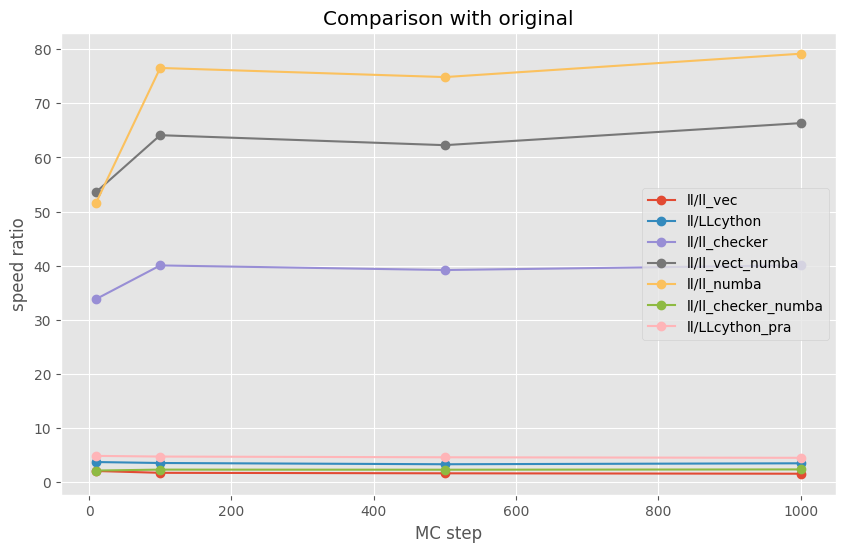

In [25]:

import numpy as np
fig, ax = plt.subplots(figsize = (10, 6))
plt.style.use('ggplot')
data_dict = {
    'll/ll_vec':np.array(results2),
    'll/LLcython':np.array(results3),
    'll/ll_checker':np.array(results4),
    'll/ll_vect_numba':np.array( results5),
    'll/ll_numba':np.array(results6),
    'll/ll_checker_numba':np.array(results7),
    'll/LLcython_pra':np.array(results8)
}

for label, y in data_dict.items():
    plt.plot(values1, np.array(results1)/y, label = label, marker = 'o', linestyle ='-')

plt.title('Comparison with original')
plt.xlabel('MC step')
plt.ylabel('speed ratio')
plt.legend()
plt.show()

In [ ]:
import ll_ene_order as leo
import numpy as np

program, nsteps, nmax, temp, pflag = ("LL", 1000, 20, 0.65, 0)
energy, order = leo.main(program, nsteps, nmax, temp, pflag )


LL: Size: 20, Steps: 10, T*: 0.650: Order: 0.406, Time: 0.148778 s


In [ ]:
fig, ax = plt.subplots(figsize = (6, 4))
x_data = np.arange(0, len(energy)) 
plt.plot(x_data, energy, linestyle ='-', color='firebrick')
#plt.plot(values2, results2,  label = 'without vectorization', marker = 'o', linestyle ='-')
#plt.title('vectorization vs original')
plt.xlabel('MC step')
plt.ylabel('Reduced Energy U/ε')
plt.title(f'Reduced Temperature , T*={temp}')
plt.legend()
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize = (6, 4))
x_data = np.arange(0, len(energy)) 
plt.plot(x_data, order, linestyle ='-', linewidth = 2)
#plt.plot(values2, results2,  label = 'without vectorization', marker = 'o', linestyle ='-')
#plt.title('vectorization vs original')
plt.xlabel('MC step')
plt.ylabel('Order Parameter, S')
plt.title(f'Reduced Temperature , T*={temp}')
plt.legend()
plt.show()